# Airbnb en Nueva York (EDA)

Este notebook realiza un analisis exploratorio completo del dataset `AB_NYC_2019.csv`, documenta las principales decisiones de limpieza y genera una version procesada lista para su uso posterior.

## Objetivos

- Cargar y revisar la estructura general del dataset.
- Detectar valores faltantes, duplicados y posibles outliers.
- Explorar variables numericas y categoricas.
- Aplicar una limpieza basica orientada a analisis y modelado.
- Dividir el dataset en train y test y guardar los archivos procesados.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CURRENT_DIR = Path.cwd().resolve()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "src" else CURRENT_DIR
SRC_DIR = PROJECT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from app import PROCESSED_DIR, clean_airbnb_data, load_dataset, save_processed_data, split_data

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = load_dataset()
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
print(f"Dimensiones del dataset: {df.shape[0]:,} filas y {df.shape[1]} columnas")
display(df.info())
display(df.describe(include="all").T)

Dimensiones del dataset: 48,895 filas y 16 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,"48,895.00",NaN,NaN,NaN,"19,017,143.24","10,983,108.39","2,539.00","9,471,945.00","19,677,284.00","29,152,178.50","36,487,245.00"
name,48879,47905,Hillside Hotel,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,"48,895.00",NaN,NaN,NaN,"67,620,010.65","78,610,967.03","2,438.00","7,822,033.00","30,793,816.00","107,434,423.00","274,321,313.00"
host_name,48874,11452,Michael,417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,48895,5,Manhattan,21661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,48895,221,Williamsburg,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,"48,895.00",NaN,NaN,NaN,40.73,0.05,40.50,40.69,40.72,40.76,40.91
longitude,"48,895.00",NaN,NaN,NaN,-73.95,0.05,-74.24,-73.98,-73.96,-73.94,-73.71
room_type,48895,3,Entire home/apt,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,"48,895.00",NaN,NaN,NaN,152.72,240.15,0.00,69.00,106.00,175.00,"10,000.00"


In [4]:
missing = (
    df.isna()
    .sum()
    .to_frame("missing_values")
    .assign(missing_pct=lambda table: table["missing_values"] / len(df) * 100)
    .sort_values("missing_values", ascending=False)
)
missing[missing["missing_values"] > 0]

,missing_values,missing_pct
last_review,10052,20.56
reviews_per_month,10052,20.56
host_name,21,0.04
name,16,0.03


In [5]:
duplicates = df.duplicated().sum()
print(f"Filas duplicadas: {duplicates}")

categorical_columns = ["neighbourhood_group", "neighbourhood", "room_type"]
for column in categorical_columns:
    print(f"\nDistribucion de {column}:")
    display(df[column].value_counts(normalize=True).mul(100).round(2).head(10).to_frame("percentage"))

Filas duplicadas: 0

Distribucion de neighbourhood_group:


,percentage
neighbourhood_group,
Manhattan,44.30
Brooklyn,41.12
Queens,11.59
Bronx,2.23
Staten Island,0.76



Distribucion de neighbourhood:


,percentage
neighbourhood,
Williamsburg,8.02
Bedford-Stuyvesant,7.60
Harlem,5.44
Bushwick,5.04
Upper West Side,4.03
Hell's Kitchen,4.00
East Village,3.79
Upper East Side,3.68
Crown Heights,3.20



Distribucion de room_type:


,percentage
room_type,
Entire home/apt,51.97
Private room,45.66
Shared room,2.37


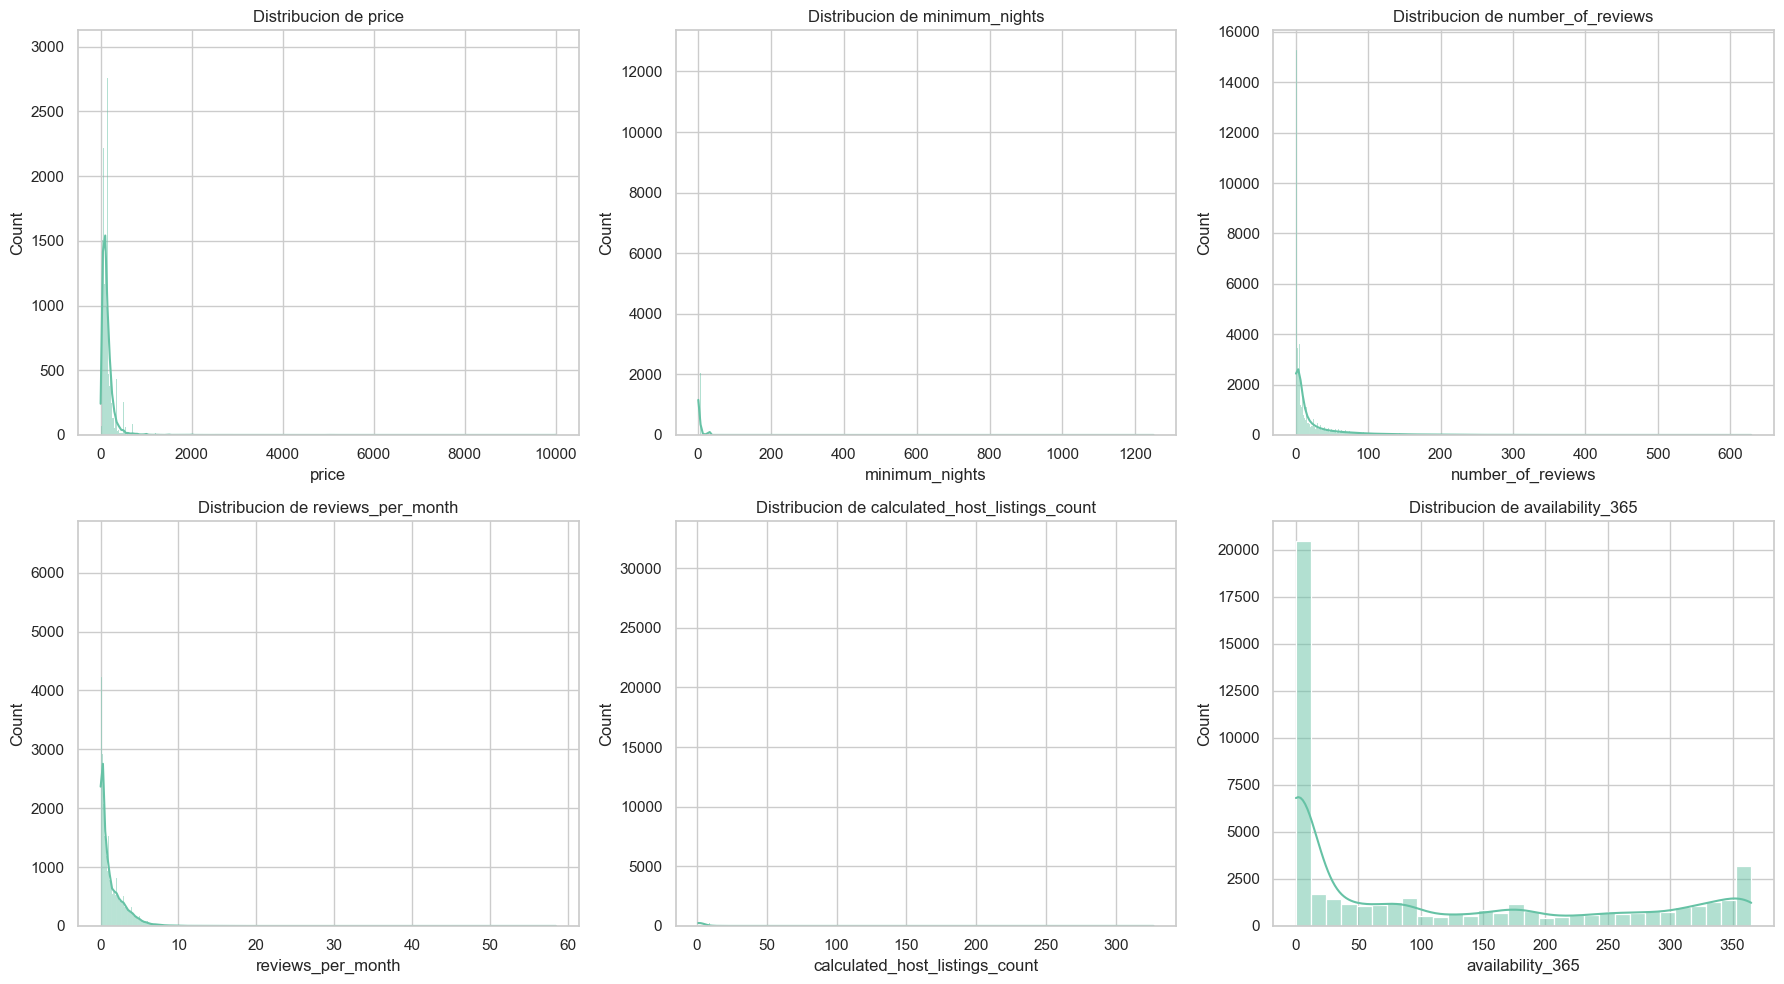

In [6]:
numeric_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, column in zip(axes.flatten(), numeric_columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Distribucion de {column}")
plt.tight_layout()

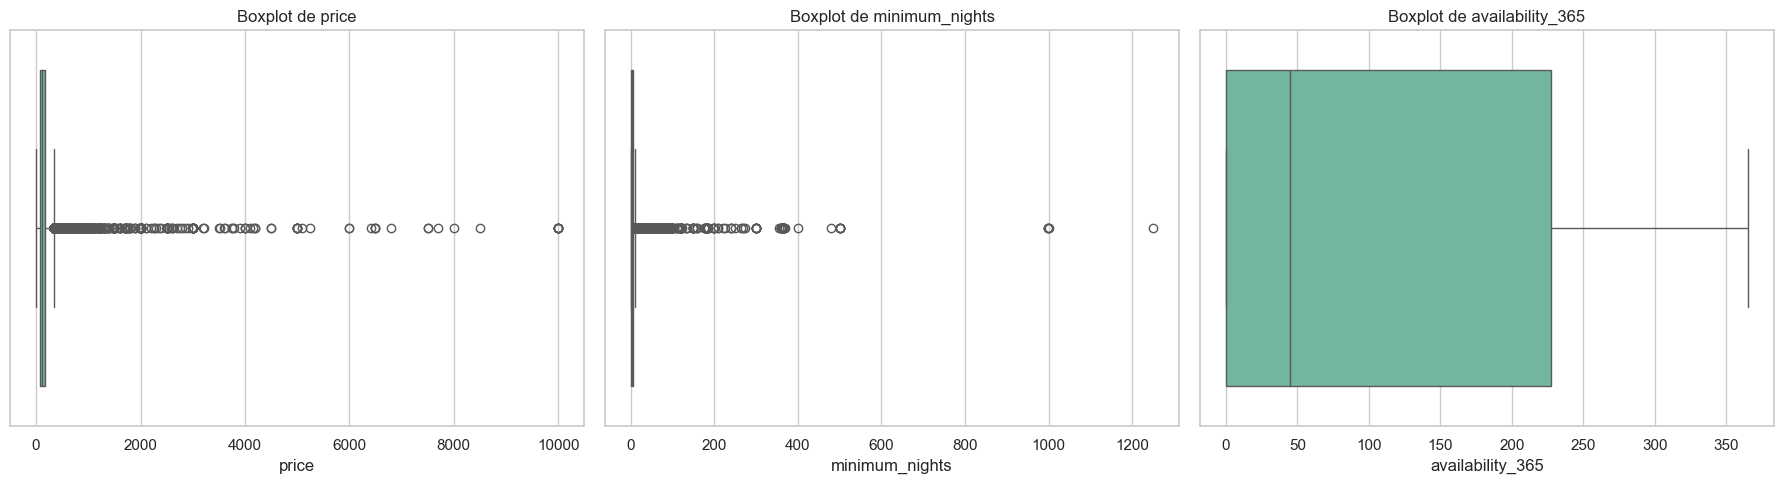

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column in zip(axes, ["price", "minimum_nights", "availability_365"]):
    sns.boxplot(x=df[column], ax=ax)
    ax.set_title(f"Boxplot de {column}")
plt.tight_layout()

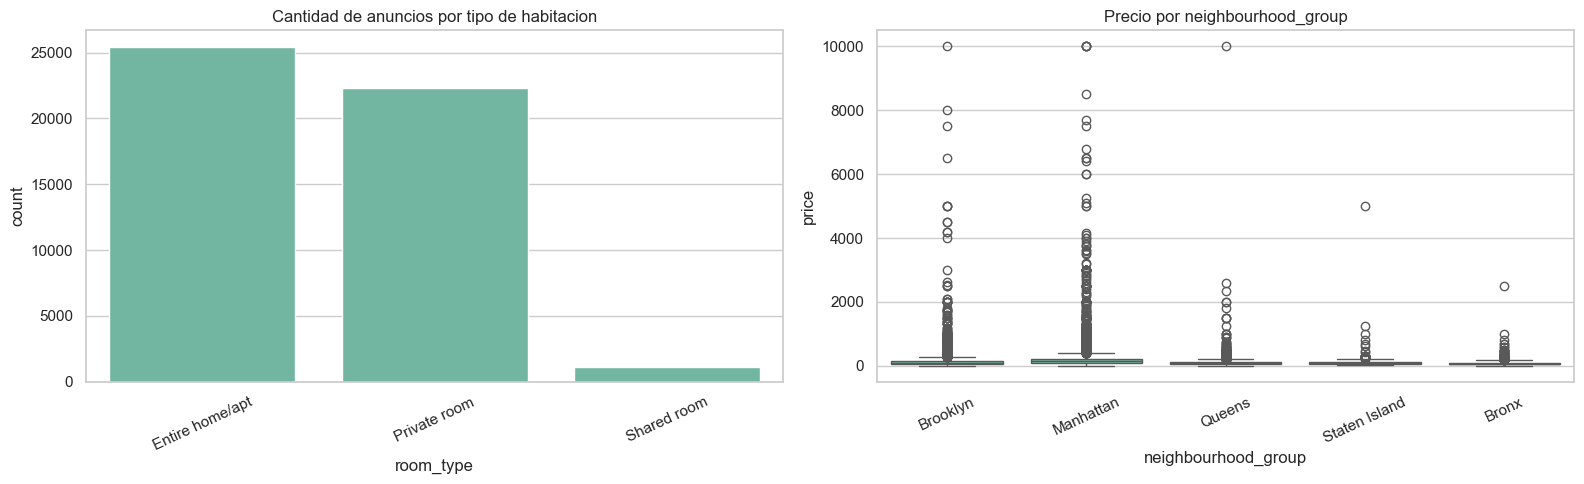

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, x="room_type", order=df["room_type"].value_counts().index, ax=axes[0])
axes[0].set_title("Cantidad de anuncios por tipo de habitacion")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=df, x="neighbourhood_group", y="price", ax=axes[1])
axes[1].set_title("Precio por neighbourhood_group")
axes[1].tick_params(axis="x", rotation=25)
plt.tight_layout()

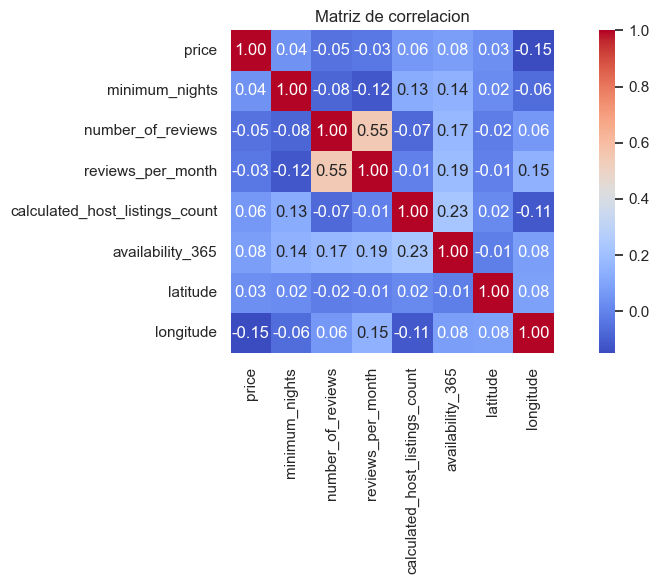

In [9]:
corr_df = df[numeric_columns + ["latitude", "longitude"]].corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matriz de correlacion")
plt.tight_layout()

## Limpieza de datos

Durante el proceso de limpieza se aplicaron estas decisiones para dejar el dataset listo para analisis y modelado:

- Se revisaron los valores faltantes y se detecto que `reviews_per_month` y `last_review` concentraban la mayor parte de los nulos.
- Se eliminaron filas duplicadas para evitar observaciones repetidas en el analisis.
- La columna `last_review` se transformo a formato fecha para poder trabajarla correctamente.
- Los valores faltantes de `reviews_per_month` se rellenaron con `0`, asumiendo que anuncios sin resenas recientes no registran actividad mensual.
- Se creo la variable `has_reviews` para identificar los anuncios con al menos una resena.
- Se creo la variable `days_since_last_review` para convertir la fecha de la ultima resena en una variable numerica util para futuros modelos.
- Se eliminaron columnas identificadoras o de texto libre como `id`, `name`, `host_id`, `host_name` y `last_review`, ya que no aportan valor directo al analisis estructurado.
- Finalmente, el dataset limpio se dividio en conjuntos de entrenamiento y prueba antes de guardarlo en `data/processed`.

In [10]:
clean_df = clean_airbnb_data(df)
train_df, test_df = split_data(clean_df)

print(f"Dataset limpio: {clean_df.shape}")
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

display(clean_df.head())

Dataset limpio: (48895, 13)
Train: (39116, 13)
Test: (9779, 13)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_reviews,days_since_last_review
0,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,0.21,6,365,1,262.00
1,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,0.38,2,355,1,48.00
2,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,0.00,1,365,0,"3,024.00"
3,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,4.64,1,194,1,3.00
4,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,0.10,1,0,1,231.00


In [11]:
save_processed_data(clean_df, train_df, test_df)
sorted(path.name for path in PROCESSED_DIR.glob("*.csv"))

['airbnb_nyc_clean.csv', 'airbnb_nyc_test.csv', 'airbnb_nyc_train.csv']

## Conclusiones

- El dataset combina variables numericas, geograficas y categoricas utiles para posteriores modelos de prediccion o segmentacion.
- `reviews_per_month` y `last_review` concentran la mayor parte de los valores faltantes, lo que tiene sentido en anuncios sin resenas.
- Variables como `price` y `minimum_nights` suelen presentar colas largas y valores extremos, por lo que conviene revisarlas antes de modelar.
- Se eliminaron identificadores y columnas de texto libre que aportan poco al analisis estructurado (`id`, `name`, `host_id`, `host_name`).
- La division train/test se realizo despues de la limpieza para dejar una base consistente lista para siguientes pasos.